# Lab 2（下）換個來源，準備建模：yfinance ＋ 特徵 ＋ 切訓練/測試

上半場你為了「一個月、20 幾天」的股價，親手寫了爬蟲、又花力氣洗乾淨。
這半場先給你一個更省力的來源，再把資料做成模型能吃的特徵，最後誠實地切出訓練與測試。

In [1]:
# 📦 先跑這一格：指定版本，避免學校電腦裝到不相容的舊版
!pip install -q pandas==2.2.3 numpy==1.26.4 matplotlib==3.10.0 yfinance==1.3.0


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# 老師的小設定：載入工具、設好中文字型（直接跑、不用改）
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Noto Sans CJK TC", "Microsoft JhengHei", "PingFang TC", "AR PL UMing CN", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
print("工具載入完成")

工具載入完成


## 🔧 第 0 步：環境檢查

In [3]:
import yfinance as yf
import pandas as pd
print("pandas  ", pd.__version__)
print("yfinance", yf.__version__)
print("環境 OK，可以開始")

pandas   2.2.3
yfinance 1.3.0
環境 OK，可以開始


## D・yfinance：一行就拿到好幾年的股價

上半場你為了一個月的資料寫了一堆程式。這次換個工具——一行，拿十年。

### D1・一行下載台積電十年股價

> 預期：抓到兩千多列（每一列是一個交易日），欄位有開高低收與成交量。

In [4]:
# 一行就抓到 2015 年到 2025 年的台積電日線
# 💡 auto_adjust=True＝自動還原除權息（讓歷史價格可比較）；multi_level_index=False＝欄位名乾淨一點
raw = yf.download("2330.TW", start="2015-01-01", end="2025-01-01",
                  auto_adjust=True, progress=False, multi_level_index=False)
print("共", len(raw), "個交易日")
raw.head()

共 2434 個交易日


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-05,102.024048,102.755403,100.561337,102.755403,32046000
2015-01-06,97.635910,100.561331,97.270232,100.561331,66778000
2015-01-07,98.001633,98.732988,97.635955,97.635955,43703000
2015-01-08,100.927048,100.927048,99.464337,99.830015,42491000
2015-01-09,98.001633,99.098666,97.270277,98.732988,61558000


### D2・這份資料乾淨又整齊——但它「幫你動過手腳」

> 預期：每一欄的缺值數都是 0（跟你上半場自己爬的髒資料差很多）。

> 先看一眼：每一格是不是空的？（回一張 True / False 的表）

In [5]:
raw.isna()   # 💡 逐格問「這格是不是空的」→ 回一張 True/False 表

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-05,False,False,False,False,False
2015-01-06,False,False,False,False,False
2015-01-07,False,False,False,False,False
2015-01-08,False,False,False,False,False
2015-01-09,False,False,False,False,False
...,...,...,...,...,...
2024-12-25,False,False,False,False,False
2024-12-26,False,False,False,False,False
2024-12-27,False,False,False,False,False


In [6]:
print(raw.isna().sum())      # 💡 每一欄缺幾格 → 全是 0，非常乾淨
# 💡 方便歸方便，但要知道：真實市場有停牌、有除權息，yfinance 都『自動幫你補好、調整好』了，
#    而且沒特別告訴你。資料很好用，但你心裡要清楚它動過手腳——這是用第三方資料的代價。

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## E・遺漏值處理：一張小表看懂各種補法

真實資料難免有缺格（NaN）。補值沒有標準答案——先用一張最小的表，把常見幾招看過一輪。

### E1・五種補法，一個一個看

> 預期：同一張小表，用五種方式處理後長相各不同；重點在**每一招的意義**。

In [7]:
# 一張迷你表：某商店連續 5 天的「來客數」與「氣溫」，中間有幾格沒記到（NaN）
demo = pd.DataFrame({
    "visitors": [120, np.nan, 135, np.nan, 150],   # 來客數
    "temp":     [28, 29, np.nan, 31, 32],          # 氣溫
})
print("原始（NaN = 當天沒記到）")
print(demo)

原始（NaN = 當天沒記到）
   visitors  temp
0     120.0  28.0
1       NaN  29.0
2     135.0   NaN
3       NaN  31.0
4     150.0  32.0


In [8]:
print("① 整列丟掉 —— 乾脆，但資料變少")
demo.dropna()

① 整列丟掉 —— 乾脆，但資料變少


,visitors,temp
0,120.0,28.0
4,150.0,32.0


In [9]:
print("② 補 0 —— 只有『沒發生＝0』才對（來客數 0 人 ✓；氣溫補 0＝0 度就荒謬 ✗）")
demo.fillna(0)

② 補 0 —— 只有『沒發生＝0』才對（來客數 0 人 ✓；氣溫補 0＝0 度就荒謬 ✗）


,visitors,temp
0,120.0,28.0
1,0.0,29.0
2,135.0,0.0
3,0.0,31.0
4,150.0,32.0


In [10]:
print("③ 補整欄平均 —— 常用在『不分先後』的特徵")
print(demo.fillna(demo.mean().round(1)))

③ 補整欄平均 —— 常用在『不分先後』的特徵
   visitors  temp
0     120.0  28.0
1     135.0  29.0
2     135.0  30.0
3     135.0  31.0
4     150.0  32.0


In [11]:
print("④ 用上一格補 —— 時間序列常用（拿昨天的值頂著，只看過去 ✓）")
demo.ffill()

④ 用上一格補 —— 時間序列常用（拿昨天的值頂著，只看過去 ✓）


,visitors,temp
0,120.0,28.0
1,120.0,29.0
2,135.0,29.0
3,135.0,31.0
4,150.0,32.0


In [12]:
print("⑤ 用下一格補 —— ⚠️ 拿明天補今天＝偷看未來，做預測時千萬別用")
demo.bfill()

⑤ 用下一格補 —— ⚠️ 拿明天補今天＝偷看未來，做預測時千萬別用


,visitors,temp
0,120.0,28.0
1,135.0,29.0
2,135.0,31.0
3,150.0,31.0
4,150.0,32.0


## F・做特徵 + 第一次切訓練/測試

有了乾淨的股價，把它變成模型能吃的「特徵」，再誠實地切成訓練與測試。

### F1・做兩個特徵：報酬率 + 5 日均線

> 預期：一張表，多了 `ret1`、`ma5` 兩欄；開頭幾列會是 NaN（天生算不出來）。

In [13]:
close = raw["Close"]                       # 💡 先把收盤價取出來
feat = pd.DataFrame({
    "close": close,
    "ret1":  close.pct_change(),           # 💡 一日報酬率：今天比昨天漲跌幾 %（只看過去 ✓）
    "ma5":   close.rolling(5).mean(),      # 💡 5 日均線：自己和前 4 天的平均（只看過去 ✓）
})
feat.head(7)   # 💡 開頭 NaN 是『特徵天生算不出來』，不是髒資料——等一下處理

,close,ret1,ma5
Date,,,
2015-01-05,102.024048,NaN,NaN
2015-01-06,97.635910,-0.043011,NaN
2015-01-07,98.001633,0.003746,NaN
2015-01-08,100.927048,0.029851,NaN
2015-01-09,98.001633,-0.028985,99.318054
2015-01-12,96.538887,-0.014926,98.221022
2015-01-13,96.904587,0.003788,98.074757


### F2・做答案（label）「明日漲」

> 預期：多一欄 `明日漲`（1＝明天收更高、0＝沒有）；最後一天要丟掉。

> 先看一個新動作：把整欄往上挪一格，好讓每一列旁邊放的是「明天」的價。

In [14]:
close.shift(-1)   # 💡 往上挪一格：每一列旁邊變成「明天」的收盤價

Date
2015-01-05      97.635910
2015-01-06      98.001633
2015-01-07     100.927048
2015-01-08      98.001633
2015-01-09      96.538887
                 ...     
2024-12-25    1061.257202
2024-12-26    1066.147583
2024-12-27    1066.147583
2024-12-30    1051.476074
2024-12-31            NaN
Name: Close, Length: 2434, dtype: float64

In [15]:
feat["明日漲"] = (close.shift(-1) > close).astype(int)   # 💡 shift(-1)＝把明天的價挪過來比
feat = feat.dropna()                                     # 💡 丟掉開頭特徵算不出來的列

In [16]:
feat = feat.iloc[:-1]                                    # 💡 丟掉最後一天：它沒有『明天』可對答案
print("特徵表大小：", feat.shape)
feat.head()

特徵表大小： (2429, 4)


,close,ret1,ma5,明日漲
Date,,,,
2015-01-09,98.001633,-0.028985,99.318054,0
2015-01-12,96.538887,-0.014926,98.221022,1
2015-01-13,96.904587,0.003788,98.074757,0
2015-01-14,95.076218,-0.018868,97.489674,1
2015-01-15,96.173218,0.011538,96.538908,1


### F3・⭐ 課程重點：答案可以看未來，特徵不行

> `明日漲` 用了「明天」的價——這是**答案欄**，本來就該寫答案，沒問題。
> 但**特徵**（`ret1`、`ma5`）只准用「今天以前」的資料。這條線，後面每個模型都會再用到。

### F4・第一次切訓練 / 測試（按時間，絕不打亂）

> 預期：前 80% 當訓練、後 20% 當測試；印出兩邊各幾列。

In [17]:
cut = int(len(feat) * 0.8)               # 💡 前 80% 的位置
train = feat.iloc[:cut]                  # 💡 較早的日子 → 拿來訓練（念書）
test  = feat.iloc[cut:]                  # 💡 較晚的日子 → 留著測試（考試）
print("訓練：", len(train), "列（較早）")
print("測試：", len(test), "列（較晚）")
# 💡 股價是時間序列：一定『前面念書、後面考試』，不能隨機打亂——不然等於拿未來的資料考過去

訓練： 1943 列（較早）
測試： 486 列（較晚）


### F5・把切點畫出來看

> 預期：一條收盤價走勢線，用一條垂直線標出訓練 / 測試的分界。

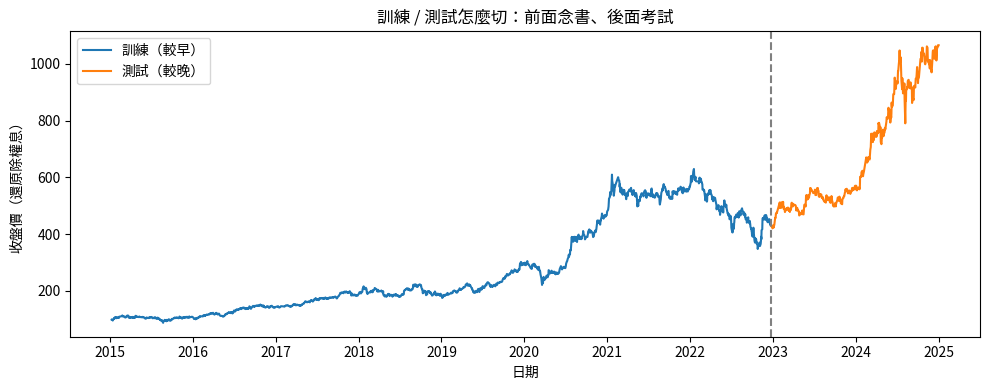

In [18]:
split_date = test.index[0]               # 💡 測試段的第一天＝分界日

plt.figure(figsize=(10, 4))
plt.plot(train.index, train["close"], label="訓練（較早）")
plt.plot(test.index, test["close"], label="測試（較晚）")
plt.axvline(split_date, color="gray", linestyle="--")   # 💡 分界線
plt.title("訓練 / 測試怎麼切：前面念書、後面考試")
plt.xlabel("日期")
plt.ylabel("收盤價（還原除權息）")
plt.legend()
plt.tight_layout()
plt.show()

### F6・存檔：把洗好的表留下來

這張 `(2429, 4)` 的表就是**模型能直接吃的形狀**。洗了半天的資料**存成 csv，下次就不用整個重跑**——實務上的標準動作。

> 預期：印出存檔完成與檔案列數。

In [19]:
feat.to_csv("data/lab2_features.csv")     # 💡 index（日期）也一起存，之後讀回來才知道每列是哪一天
print("已存 data/lab2_features.csv：", feat.shape[0], "列", feat.shape[1], "欄")
print("欄位：", list(feat.columns))

已存 data/lab2_features.csv： 2429 列 4 欄
欄位： ['close', 'ret1', 'ma5', '明日漲']


## 🔑 這一段你做了什麼

1. 用 yfinance 一行拿到十年股價（也知道它幫你調整過、要心裡有數）
2. 看過遺漏值的幾種補法，和各自的意義
3. 把股價做成特徵（報酬率、均線）＋ 答案（明日漲）
4. 第一次把資料切成訓練 / 測試——**按時間切，不能打亂**
5. 把特徵表**存成 `data/lab2_features.csv`**——洗好的資料要留著

下一個 Lab：教電腦「猜漲跌」。**今天做特徵、按時間切 train/test 的這套功夫，下一個 Lab 整堂都在用。**